In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load `torch`. Note the version on colab can lag behind the most current release. If you need something new you can install using e.g. !pip3 install torch==1.4.0

In [ ]:
import torch
import torch.nn as nn
import torch.utils.data
assert(torch.cuda.is_available()) # if this fails go to Runtime -> Change runtime type -> Set "Hardware Accelerator"
print("Torch version:", torch.__version__)

Torch version: 2.8.0+cu126


## Utilities

We'll be using a "one hot" encoding of DNA sequence as the input to our CNN. This can actually be a bottleneck as it runs on the CPU so we use Cython to speed things up.  

In [ ]:
%load_ext Cython

The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [ ]:
%%cython

import numpy as np
np.get_include() # do we need this on colab?
cimport cython
cimport numpy as np

cdef dict bases={ 'A':<int>0, 'C':<int>1, 'G':<int>2, 'T':<int>3 }

@cython.boundscheck(False)
def one_hot( str string ):
    cdef np.ndarray[np.float32_t, ndim=2] res = np.zeros( (4,len(string)), dtype=np.float32 )
    cdef int j
    for j in range(len(string)):
        if string[j] in bases: # bases can be 'N' signifying missing: this corresponds to all 0 in the encoding
            res[ bases[ string[j] ], j ]=float(1.0)
    return(res)


# Pytorch basics

`pytorch` (as opposed to e.g. Theano, Tensorflow 1) uses *eager execution*: this lets you write computations as python code that you can test and debug, and later
1.   Backprop through (i.e. get gradients with respect to inputs)
2.   Run on the GPU for (hopefully!) big speedups.

Here's an example:

In [ ]:
x_np = one_hot("CCGCGNGGNGGCAG")
x_tensor = torch.tensor(x_np)
print(x_tensor)
torch.sum(x_tensor, 1)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


tensor([1., 4., 7., 0.])

`torch` has equivalents for most `numpy` operations, for example here we got the row sums to check how often each base appeared in our sequence.

As a more exciting example, `torch.nn.functional` has convolutions implemented for us.

In [ ]:
import torch.nn.functional as F
help(F.conv1d)

Help on built-in function conv1d in module torch:

conv1d(...)
    conv1d(input, weight, bias=None, stride=1, padding=0, dilation=1, groups=1) -> Tensor

    Applies a 1D convolution over an input signal composed of several input
    planes.

    This operator supports :ref:`TensorFloat32<tf32_on_ampere>`.

    See :class:`~torch.nn.Conv1d` for details and output shape.

    Note:
        In some circumstances when given tensors on a CUDA device and using CuDNN, this operator may select a nondeterministic algorithm to increase performance. If this is undesirable, you can try to make the operation deterministic (potentially at a performance cost) by setting ``torch.backends.cudnn.deterministic = True``. See :doc:`/notes/randomness` for more information.

    Note:
        This operator supports complex data types i.e. ``complex32, complex64, complex128``.


    Args:
        input: input tensor of shape :math:`(\text{minibatch} , \text{in\_channels} , iW)`
        weight: filters of sha

Notice `conv1d` expects
1. `input` to have shape batchsize x #input_channels x length (as a warning, `tensorflow` expects batchsize x length x #input_channels!)
2. `weight` (i.e. the filters) to have shape #output_channels x #input_channels x filter_width.

We can make a random tensor for the filters (weights), and then execute the convolution

In [ ]:
x_batch = x_tensor[None,:,:] # make a "batch" of size 1
filter_width = 5
my_weights = torch.randn(1, 4, filter_width) # 1 output channels, 4 input channels, filter width = 5
convolution_output = F.conv1d(x_batch, my_weights)
convolution_output

tensor([[[-0.2143, -0.3662,  1.0187,  0.4208,  0.3634,  0.4716,  0.4250,
           0.0159, -1.0235,  0.0851]]])

Let's check `torch` got the right answer. Here's the calculation for the first position (for data point 0 and output channel 0):

In [ ]:
(x_batch[0,:,0:filter_width] * my_weights[0,:,:]).sum()

tensor(-0.2143)

## Task

**Write a for loop to manually calculate the remaining terms in the convolution [1 point]**

In [ ]:
my_convolution_output = torch.zeros([1, 1, x_batch.shape[2] - (filter_width-1)]) #empty tensor to store manual convolution result
for i in range(my_convolution_output.shape[2]): # every convolution position
    my_convolution_output[0,0,i] = (x_batch[0, :, i:i+filter_width] * my_weights[0, :, :]).sum() # performing convolution
assert( ((convolution_output - my_convolution_output).abs() < 1e-6).all() ) # check

Note the effect of the (0 padded) convolution on the shape of the output: the sequence length has gone from 14 to 10.

In [ ]:
print( x_batch.shape, convolution_output.shape )

torch.Size([1, 4, 14]) torch.Size([1, 1, 10])


Without padding we lose (filter_width-1) positions.

`torch` has nice built in utilities for setting up neural network (NN) layers. For example, we can make a 1D convolutional layer like this:

In [ ]:
torch.manual_seed(2) # I played with different initialization here!
my_first_conv_layer = nn.Conv1d(4, 1, 14, padding = 0) # 4 input channels, 1 output channels, filter width 14, no padding
my_first_conv_layer

Conv1d(4, 1, kernel_size=(14,), stride=(1,))

We can use this layer like a function (applied to tensors):

In [ ]:
my_first_conv_layer(x_batch)

tensor([[[-0.3852]]])

But if `my_first_conv_layer` behaves like a function, where are the weights? They're there (along with biases), but they're a little hidden:

In [ ]:
list(my_first_conv_layer.parameters())

[Parameter containing:
 tensor([[[ 0.0307, -0.0318,  0.0366, -0.0068,  0.0571,  0.0318, -0.0154,
           -0.1080,  0.0305, -0.1183,  0.0176,  0.0089, -0.0294,  0.1093],
          [ 0.0089,  0.0554,  0.0566, -0.0788, -0.0514,  0.1285, -0.1309,
           -0.0091, -0.0106,  0.0948, -0.0127,  0.0352, -0.0064, -0.0748],
          [-0.0757, -0.0649, -0.1214, -0.0867,  0.0314,  0.0879,  0.0066,
           -0.0613,  0.0587, -0.0513, -0.0296, -0.0733, -0.0420, -0.1238],
          [ 0.0570,  0.0520,  0.0265,  0.0656,  0.0566,  0.0059,  0.0142,
            0.0102,  0.0713,  0.0898,  0.0960,  0.0775, -0.0326, -0.0059]]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0272], requires_grad=True)]

But where did these numbers come from? `torch` by default initializes using the very reasonable [Kaiming/He initalization](https://arxiv.org/abs/1502.01852) which aims to keep the variance of the hidden layer activations reasonably stable (constant in expectation) through the network.

# My First Convolutional Neural Network

We're ready to make the simplest CNN possible where we just take the max over all the convolution outputs:

In [ ]:
def my_simplest_CNN(x):
    net = my_first_conv_layer(x)
    net = net[:,0,:] # only one output channel!
    # take maximum over channel ("global max pooling")
    net = torch.max(net, dim=1).values # max returns namedtuple (values, indices)
    net = torch.sigmoid(net) # aka logistic to get output in [0,1]
    return(net)

my_simplest_CNN(x_batch)

tensor([0.4049])

## Loading data

To test this out we need some data! Our first task will be predict binding of the important transcriptional repressor CTCF in a human lung cancer cell line called A549. The data is available from ENCODE including merging replicate experiments using the "irreproducible discovery rate" (IDR) [paper](https://arxiv.org/abs/1110.4705) [code](https://github.com/spundhir/idr). Genomics data representing discrete binding events is typically stored in the  `bed` format, which is described on the UCSC Genome Browser [website](https://genome.ucsc.edu/FAQ/FAQformat.html#format1). This bed file has some additional columns we will ignore.

In [ ]:
import pandas as pd
DATADIR = "/content/drive/My Drive/ML4fungen/Assignment 2/" # might need to change this
binding_data = pd.read_csv(DATADIR + "ENCFF300IYQ.bed.gz", sep='\t', usecols=range(6), names=("chrom","start","end","name","score","strand"))
binding_data = binding_data[ ~binding_data['chrom'].isin(["chrX","chrY"]) ] # only keep autosomes (non sex chromosomes)
binding_data = binding_data.sort_values(['chrom', 'start']).drop_duplicates() # sort so we can interleave negatives
binding_data[:10]

,chrom,start,end,name,score,strand
3417,chr1,714156,714372,.,1000,.
28093,chr1,805243,805372,.,1000,.
32029,chr1,840059,840248,.,1000,.
17195,chr1,848298,848514,.,1000,.
6610,chr1,855056,855272,.,1000,.
10598,chr1,856479,856695,.,1000,.
15904,chr1,858493,858709,.,1000,.
16616,chr1,860345,860561,.,1000,.
10818,chr1,860967,861183,.,1000,.
31703,chr1,873565,873753,.,1000,.


`chrom` is the chromosome (we filter out the sex chromosomes X and Y to avoid bias from these being haploid, you could try keeping them though). `start` and `end` are positions in the genome. `name` and `strand` aren't used here. Some genomics assays (e.g. RNA-seq) correspond to one strand of the DNA or the other. However, for our purposes at least we can consider ChIP-seq and ATAC-seq as "unstranded", which is why that column is all "." rather than + or -.  `score` is a quantitative measure of binding. We'll ignore this for now (since all these peaks are statistically significant), but you could try to incorporate it in your model training if you want (e.g. multitask for binary binding plus predicting `score`).

We'll split the binding data into training, validation (chroms 2 and 3, ~) and test (chrom 1), which represents about 14% of the training data we have:

In [ ]:
test_chromosomes = ["chr1"]
test_data = binding_data[ binding_data['chrom'].isin( test_chromosomes ) ]

validation_chromosomes = ["chr2","chr3"]
validation_data = binding_data[ binding_data['chrom'].isin(validation_chromosomes) ]

train_chromosomes = ["chr%i" % i for i in range(4, 22+1)]
train_data = binding_data[ binding_data['chrom'].isin( train_chromosomes ) ]

test_data.shape[0] / binding_data.shape[0], validation_data.shape[0] / binding_data.shape[0]

(0.0924340093163318, 0.1410859643344469)

We'll also need the human genome, which we provide here as a pickle since it's faster to load compared to reading in a text file.

It's worth knowing that the human genome has different *versions* that are released as more missing parts are resolved by continued sequencing and assembly efforts. Version `GRCh37` (also called `hg19`) was released in 2009, and `GRCh38` (`hg38`) was released in 2013. We'll be using `hg19` here but `GRCh38` is finally becoming more standard so always check your data is what you think it is.

This will take a minute or two.

In [ ]:
import pickle
#genome = pickle.load(open(DATADIR+"hg38.pkl","rb")) # this is here in case there's hg38 data you want to analyse
genome = pickle.load(open(DATADIR+"hg19.pickle","rb"))

`genome` is just a dictionary where the keys are the chromosome names and the values are strings representing the actual DNA:

In [ ]:
genome["chr13"][100000000:100000010]

'GTGATAACGT'

You'll find a substantial proportion of each chromosome is "N"s:

In [ ]:
genome["chr13"].count("N") / len(genome["chr13"])

0.17000973119030308

Ns represents "missing" regions, typically because the region has too many repetitive sequences making mapping impossible, which is especially the case in [centrosomes](https://en.wikipedia.org/wiki/Centrosome) and [telomeres](https://en.wikipedia.org/wiki/Telomere). Resolving these difficult to map regions is an ongoing effort.

We'll use the `torch` data loading utilities (nicely documented [here](https://pytorch.org/docs/stable/data.html)) to handle
1. Grouping individual (x,y) pairs into minibatches.
2. Converting `numpy` arrays into `torch` tensors.

We could also use `num_workers>0` to have a background process generating the next batch using the CPU while the GPU is working, but in my experience this actually slows things down. If you were in a computer vision setting where you wanted to do intensive [data augmentation](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html) it might make a difference.

In [ ]:
# positive example: binding of protein onto sequence (ChIP-seq (TF ChIP-seq))
# negative example: the ones that do not overlap with the positive examples
# for chip-seq data: also shuffling nucleotides can be done to keep the GC content the same as positive example
# because sequencing has biases with GC content and this would be a way to "fix it"
class BedPeaksDataset(torch.utils.data.IterableDataset):

    def __init__(self, atac_data, genome, context_length):
        super(BedPeaksDataset, self).__init__()
        self.context_length = context_length
        self.atac_data = atac_data
        self.genome = genome

    def __iter__(self):
        prev_end = 0
        prev_chrom = ""
        for i,row in enumerate(self.atac_data.itertuples()):
            midpoint = int(.5 * (row.start + row.end))
            seq = self.genome[row.chrom][ midpoint - self.context_length//2:midpoint + self.context_length//2]
            yield(one_hot(seq), np.float32(1)) # positive example

            if prev_chrom == row.chrom and prev_end < row.start:
                midpoint = int(.5 * (prev_end + row.start))
                seq = self.genome[row.chrom][ midpoint - self.context_length//2:midpoint + self.context_length//2]
                yield(one_hot(seq), np.float32(0)) # negative example midway inbetween peaks, could randomize

            prev_chrom = row.chrom
            prev_end = row.end

train_dataset = BedPeaksDataset(train_data, genome, 100)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1000, num_workers = 0)

train_data

,chrom,start,end,name,score,strand
6094,chr10,119905,120121,.,977,.
18051,chr10,122432,122648,.,1000,.
14300,chr10,183139,183355,.,1000,.
19341,chr10,276844,276914,.,1000,.
17727,chr10,325694,325910,.,1000,.
...,...,...,...,...,...,...
8866,chr9,140862899,140863115,.,998,.
31972,chr9,140916866,140917028,.,1000,.
22970,chr9,140948983,140949199,.,1000,.
4812,chr9,140960493,140960709,.,1000,.


## Training

Let's train our super simple CNN using stochastic gradient descent:

In [ ]:
import timeit
start_time = timeit.default_timer()

torch.set_grad_enabled(True) # we'll need gradients

for epoch in range(10): # run for this many epochs
    losses = []
    accuracies = []
    for (x,y) in train_dataloader: # iterate over minibatches

        output = my_simplest_CNN(x) # forward pass
        # in practice (and below) we'll use more numerically stable built-in
        # functions for the loss
        loss = - torch.mean( y * torch.log(output) + (1.-y) * torch.log(1.-output) )
        loss.backward() # back propagation

        # iterate over parameter tensors: just the layer1 weights and bias here
        for parameters in my_first_conv_layer.parameters():
            parameters.data -= 1.0 * parameters.grad # in practive reduce or adapt learning rate
            parameters.grad.data.zero_() # torch accumulates gradients so need to reset

        losses.append(loss.detach().numpy()) # convert back to numpy
        accuracy = torch.mean( ( (output > .5) == (y > .5) ).float() )
        accuracies.append(accuracy.detach().numpy())

    elapsed = float(timeit.default_timer() - start_time)
    print("Epoch %i %.2fs/epoch Loss: %.4f Acc: %.4f" % (epoch+1, elapsed/(epoch+1), np.mean(losses), np.mean(accuracies)))


Epoch 1 1.85s/epoch Loss: 0.5535 Acc: 0.7388
Epoch 2 1.86s/epoch Loss: 0.4895 Acc: 0.7632
Epoch 3 1.85s/epoch Loss: 0.4492 Acc: 0.7939
Epoch 4 1.87s/epoch Loss: 0.3835 Acc: 0.8322
Epoch 5 1.87s/epoch Loss: 0.3422 Acc: 0.8540
Epoch 6 2.06s/epoch Loss: 0.3321 Acc: 0.8574
Epoch 7 2.31s/epoch Loss: 0.3286 Acc: 0.8587
Epoch 8 2.26s/epoch Loss: 0.3269 Acc: 0.8589
Epoch 9 2.22s/epoch Loss: 0.3260 Acc: 0.8591
Epoch 10 2.19s/epoch Loss: 0.3255 Acc: 0.8592


So we can get pretty decent accuracy even with this very simple CNN (although I cheated a bit by trying a few random seeds and knowing that the CTCF consensus motif is 14nt long so would require a width 14 filter).

In [ ]:
validation_dataset = BedPeaksDataset(validation_data, genome, 100)
validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size=1000)
accuracies = [ torch.mean( ( (my_simplest_CNN(x)  > .5) == (y > .5) ).float() ).detach().cpu().numpy() for (x,y) in validation_dataloader ]
np.mean(accuracies)

np.float32(0.83062035)

The validation accuracy is very similiar to the train accuracy, suggesting we're not overfitting (as we would expect with such a simple model).

## Model interpretation

Since this model used only a single convolutional filter it's very easy to interpret how it's making predictions. In genetics it's common to plot position weight matrices as "sequence logos":

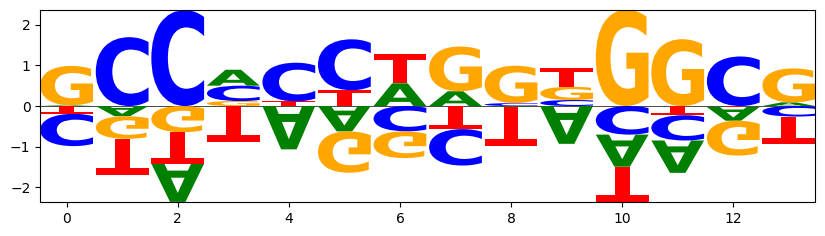

In [ ]:
!pip install logomaker
import logomaker
pwm = my_first_conv_layer.weight.detach().cpu().numpy().squeeze()
pwm -= pwm.mean(0, keepdims=True) # remove spurious degrees of freedom
pwm_df = pd.DataFrame(data = pwm.transpose(), columns=("A","C","G","T"))
crp_logo = logomaker.Logo(pwm_df) # CCACCAGG(G/T)GGCG

Characters above (below) the x-axis correspond to positive (negative) values. Our model has some additional degrees of freedom (we could add a constant k to each column of the filter and substract k from the bias without changing the prediction) which we remove. Compare this to the "known" sequence motif: [JASPAR CTCF](http://jaspar.genereg.net/matrix/MA0139.1/) to see it's a pretty good match.

# A full LeNet-type CNN

Let's see if we can do better with a full CNN. While it's not strictly necessary it's convenient to encapsulate the model as a class inheriting from `nn.Module`. This allows automatic handling of things like:
1. Extracting all model parameters.
2. Setting all layers to train or eval mode (for layers like dropout that behave differently in the two settings).
Note that here we used the model architecture to specify the length of sequence (the "sequence context") that is considered (stored as cnn_1d.seq_len). "num_chunks" here corresponds to the sequence length of the hidden layer after the last convolutional layer. The other common approach is to instead specify the sequence context and use the formula we covered in class to calculate the sequence length L for each each hidden layer (you're welcome to try implementing that approach!)

In [ ]:
class CNN_1d(nn.Module):

    def __init__(self,
                 n_output_channels = 1,
                 filter_widths = [15, 5],
                 num_chunks = 5,
                 max_pool_factor = 4,
                 nchannels = [4, 32, 32],
                 n_hidden = 32,
                 dropout = 0.2):

        super(CNN_1d, self).__init__()
        self.rf = 0 # running estimate of the receptive field
        self.chunk_size = 1 # running estimate of num basepairs corresponding to one position after convolutions

        conv_layers = []
        for i in range(len(nchannels)-1):
            conv_layers += [ nn.Conv1d(nchannels[i], nchannels[i+1], filter_widths[i], padding = 0),
                        nn.BatchNorm1d(nchannels[i+1]), # tends to help give faster convergence: https://arxiv.org/abs/1502.03167
                        nn.Dropout2d(dropout), # popular form of regularization: https://jmlr.org/papers/v15/srivastava14a.html
                        nn.MaxPool1d(max_pool_factor),
                        nn.ELU(inplace=True)  ] # popular alternative to ReLU: https://arxiv.org/abs/1511.07289
            assert(filter_widths[i] % 2 == 1) # assume this
            self.rf += (filter_widths[i] - 1) * self.chunk_size
            self.chunk_size *= max_pool_factor

        # If you have a model with lots of layers, you can create a list first and
        # then use the * operator to expand the list into positional arguments, like this:
        self.conv_net = nn.Sequential(*conv_layers)

        self.seq_len = num_chunks * self.chunk_size + self.rf # amount of sequence context required

        print("Receptive field:", self.rf, "Chunk size:", self.chunk_size, "Number chunks:", num_chunks)

        self.dense_net = nn.Sequential( nn.Linear(nchannels[-1] * num_chunks, n_hidden),
                                        nn.Dropout(dropout),
                                        nn.ELU(inplace=True),
                                        nn.Linear(n_hidden, n_output_channels) )

    def forward(self, x):
        net = self.conv_net(x)
        net = net.view(net.size(0), -1)
        net = self.dense_net(net)
        return(net)

cnn_1d = CNN_1d()

print("Input length:", cnn_1d.seq_len)

cnn_1d

Receptive field: 30 Chunk size: 16 Number chunks: 5
Input length: 110


CNN_1d(
  (conv_net): Sequential(
    (0): Conv1d(4, 32, kernel_size=(15,), stride=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Dropout2d(p=0.2, inplace=False)
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): ELU(alpha=1.0, inplace=True)
    (5): Conv1d(32, 32, kernel_size=(5,), stride=(1,))
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (9): ELU(alpha=1.0, inplace=True)
  )
  (dense_net): Sequential(
    (0): Linear(in_features=160, out_features=32, bias=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): ELU(alpha=1.0, inplace=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

The `torch` output nicely illustrates the various layers in our network. We have two convolutional units each doing conv -> batchnorm -> dropout -> maxpooling -> activation, followed by two layers of dense network, including a dropout layer.

We'll recreate the dataloaders to satisfy the input sequence length requirement of the new model.


In [ ]:
train_dataset = BedPeaksDataset(train_data, genome, cnn_1d.seq_len)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1000, num_workers = 0)
validation_dataset = BedPeaksDataset(validation_data, genome, cnn_1d.seq_len)
validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size=1000)


## Transfering to the GPU
The previous example actually ran on the CPU. Now we're using a more complex model it'll be worth running on the GPU. To do that we need to transfer both model and data. Transfering the model:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_1d.to(device)
print(device)

cuda


Check that this says `cuda` not `cpu`! You need to go to Runtime -> Change runtime type -> Set "Hardware Accelerator" -> GPU (or TPU) if not.

Next we'll set up the optimizer. `torch` has a number of [optimizers](https://pytorch.org/docs/stable/optim.html), most of which are variants of SGD. [Adam](https://arxiv.org/abs/1412.6980) with the [AMSgrad convergence fix](https://openreview.net/forum?id=ryQu7f-RZ) is a good default in my experience.

In [ ]:
optimizer = torch.optim.Adam(cnn_1d.parameters(), amsgrad=True)

We define a training loop which can be used for both training and validation loops by setting the `train_flag`.

In [ ]:
def run_one_epoch(train_flag, dataloader, cnn_1d, optimizer, device="cuda"):

    torch.set_grad_enabled(train_flag)
    cnn_1d.train() if train_flag else cnn_1d.eval()

    losses = []
    accuracies = []

    for (x,y) in dataloader: # collection of tuples with iterator

        (x, y) = ( x.to(device), y.to(device) ) # transfer data to GPU

        output = cnn_1d(x) # forward pass
        output = output.squeeze() # remove spurious channel dimension
        loss = F.binary_cross_entropy_with_logits( output, y ) # numerically stable

        if train_flag:
            loss.backward() # back propagation
            optimizer.step()
            optimizer.zero_grad()

        losses.append(loss.detach().cpu().numpy())
        accuracy = torch.mean( ( (output > 0.0) == (y > 0.5) ).float() ) # output is in logit space so threshold is 0.
        accuracies.append(accuracy.detach().cpu().numpy())

    return( np.mean(losses), np.mean(accuracies) )

## Training
Ok let's train! We'll keep track of validation loss to do [early stopping](https://en.wikipedia.org/wiki/Early_stopping): if we don't see any improvement in the validation validation loss for 10 consecutive epochs then we stop training. This will take a few minutes.

In [ ]:
train_accs = []
val_accs = []
patience = 10 # for early stopping
patience_counter = patience
best_val_loss = np.inf
check_point_filename = 'cnn_1d_checkpoint.pt' # to save the best model fit to date
for epoch in range(100):
    start_time = timeit.default_timer()
    train_loss, train_acc = run_one_epoch(True, train_dataloader, cnn_1d, optimizer, device)
    val_loss, val_acc = run_one_epoch(False, validation_dataloader, cnn_1d, optimizer, device)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    if val_loss < best_val_loss:
        torch.save(cnn_1d.state_dict(), check_point_filename)
        best_val_loss = val_loss
        patience_counter = patience
    else:
        patience_counter -= 1
        if patience_counter <= 0:
            cnn_1d.load_state_dict(torch.load(check_point_filename)) # recover the best model so far
            break
    elapsed = float(timeit.default_timer() - start_time)
    print("Epoch %i took %.2fs. Train loss: %.4f acc: %.4f. Val loss: %.4f acc: %.4f. Patience left: %i" %
          (epoch+1, elapsed, train_loss, train_acc, val_loss, val_acc, patience_counter ))

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1542: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn(


Epoch 1 took 2.84s. Train loss: 0.5369 acc: 0.7186. Val loss: 0.4287 acc: 0.7913. Patience left: 10
Epoch 2 took 3.52s. Train loss: 0.4474 acc: 0.7776. Val loss: 0.3631 acc: 0.8275. Patience left: 10
Epoch 3 took 2.08s. Train loss: 0.3947 acc: 0.8100. Val loss: 0.3096 acc: 0.8637. Patience left: 10
Epoch 4 took 2.05s. Train loss: 0.3442 acc: 0.8411. Val loss: 0.2619 acc: 0.8894. Patience left: 10
Epoch 5 took 2.07s. Train loss: 0.3057 acc: 0.8628. Val loss: 0.2464 acc: 0.8977. Patience left: 10
Epoch 6 took 2.04s. Train loss: 0.2832 acc: 0.8752. Val loss: 0.2301 acc: 0.9065. Patience left: 10
Epoch 7 took 2.64s. Train loss: 0.2678 acc: 0.8855. Val loss: 0.2246 acc: 0.9078. Patience left: 10
Epoch 8 took 3.34s. Train loss: 0.2571 acc: 0.8915. Val loss: 0.2034 acc: 0.9158. Patience left: 10
Epoch 9 took 2.05s. Train loss: 0.2471 acc: 0.8950. Val loss: 0.2018 acc: 0.9194. Patience left: 10
Epoch 10 took 2.09s. Train loss: 0.2404 acc: 0.8989. Val loss: 0.1944 acc: 0.9214. Patience left: 10

Rather than trying to stare at those numbers let's plot training and validation accuracy:

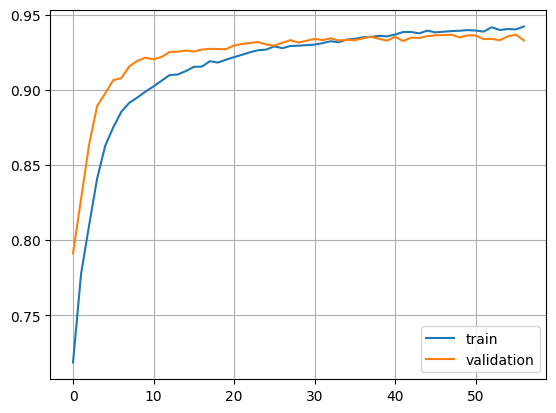

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="validation")
plt.legend()
plt.grid(which="both")

Unusually the validation accuracy is higher than the train accuracy in some places! This could be due to (at least) two factors:
1. Relatively small validation set so the estimate is noisy.
2. Dropout introduces noise into the predictions during training but not validation (as it should).
We could actually test this by evaluating on the training data without dropout:

In [ ]:
train_loss, train_acc = run_one_epoch(False, train_dataloader, cnn_1d, optimizer, device)
val_loss, val_acc = run_one_epoch(False, validation_dataloader, cnn_1d, optimizer, device)
print(train_acc, val_acc)

0.95185584 0.9365286


As expected, the validation accuracy is a little lower. Strictly speaking we should also check performance on the test set since we used the validation set to do early stopping.

In [ ]:
test_dataset = BedPeaksDataset(test_data, genome, cnn_1d.seq_len)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1000)
test_loss, test_acc = run_one_epoch(False, test_dataloader, cnn_1d, optimizer, device)
test_acc

np.float32(0.9422259)

Nice, the test set accuracy is high too.

## Model interpretation

Model interpretation is an active area of research for CNNs. Two baseline approaches in genomics are *in silico* mutagenesis and saliency maps. Good approaches exist for explaining the prediction for a single instance: explaining how the model works globally is still a challenge in general.

### in silico mutatgenesis

This approach is specific to genomics where we can imagine making individual "point" mutations (changing just one base) and seeing what effect that has on the model's prediction. In computer vision there isn't a direct analogy: deleting or changing a single pixel would rarely (if ever) change the prediction we would expect (although CNNs are not necessarily robust to such changes - adversarial training attempts to make them so).  

*in silico* mutagenesis can be used both for model interpretation (as we do here) and predicting the effects of real mutations/genetic differences between individuals.

We'll just run mutagenesis for the first batch of the validation data:

In [ ]:
torch.set_grad_enabled(False)
for (x_cpu,y_cpu) in validation_dataloader:
    x = x_cpu.to(device)
    y = y_cpu.to(device)
    output = cnn_1d(x).squeeze()
    output = torch.sigmoid(output)
    delta_output = torch.zeros_like(x, device=device)
    # loop over all positions changing to each position nucleotide
    # note everything is implicitly parallelized over the batch here
    for seq_idx in range(cnn_1d.seq_len): # iterate over sequence
        for nt_idx in range(4): # iterate over nucleotides
            x_prime = x.clone() # make a copy of x
            x_prime[:,:,seq_idx] = 0. # change the nucleotide to nt_idx
            x_prime[:,nt_idx,seq_idx] = 1.
            output_prime = cnn_1d(x_prime).squeeze()
            output_prime = torch.sigmoid(output_prime)
            delta_output[:,nt_idx,seq_idx] = output_prime - output
    break # just do this for first batch

Note how computationally expensive this is: for every instance we do inference $4 \times L$ times (we could make this $3 \times L$ easily enough).

We'll visualize just four (2 positive 2 negative) examples:

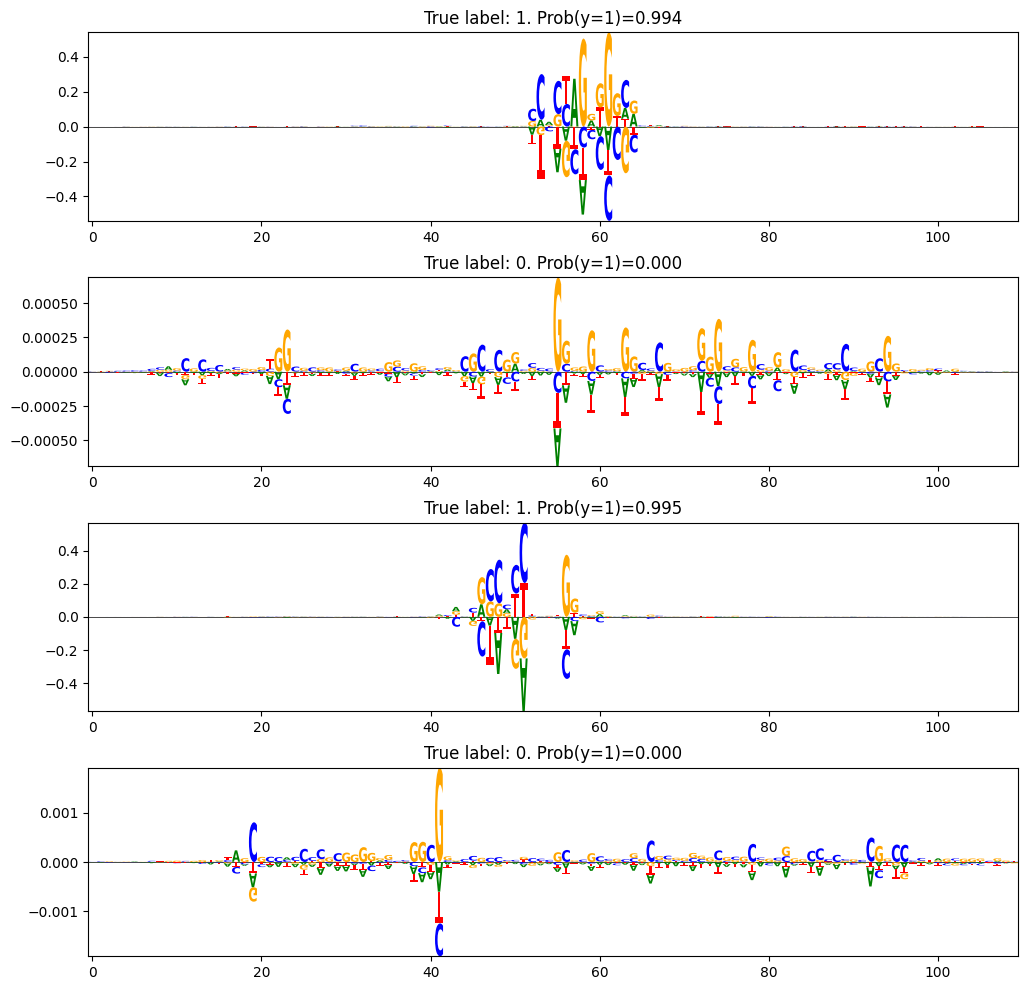

In [ ]:
delta_output_np = delta_output.detach().cpu().numpy()
delta_output_np -= delta_output_np.mean(1, keepdims=True)
output_np = output.detach().cpu().numpy()
plt.figure(figsize = (12,12))
for i in range(1,5):
    ax = plt.subplot(4,1,i)
    pwm_df = pd.DataFrame(data = delta_output_np[i,:,:].transpose(), columns=("A","C","G","T"))
    crp_logo = logomaker.Logo(pwm_df, ax = ax) # CCGCGNGGNGGCAG or CTGCCNCCNCGCGG
    plt.title("True label: %i. Prob(y=1)=%.3f" % (y_cpu[i],output_np[i]))

plt.subplots_adjust(hspace = 0.3)

Note the difference in the y-axis scales! For the two positive examples there are clear regions in the sequence that if disrupted significantly impact the prediction. For the negative examples there is a scattering of "mutations" that would effect the prediction, presumably by randomly introducing a sequence that looks a little like the CTCF motif (we don't expect any specific features in these negative sequences).

### Saliency maps

This is the simplest approach to leverage the same backprop machinery that we use during training. The trick is that instead of taking the gradient w.r.t. parameters we'll now take the gradient w.r.t. inputs `x`. Specifically here we'll get the gradient of $P(y=1|x)$ w.r.t x. The `saliency` itself is defined as that gradient elementwise multiplied with `x` itself.

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1542: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn(


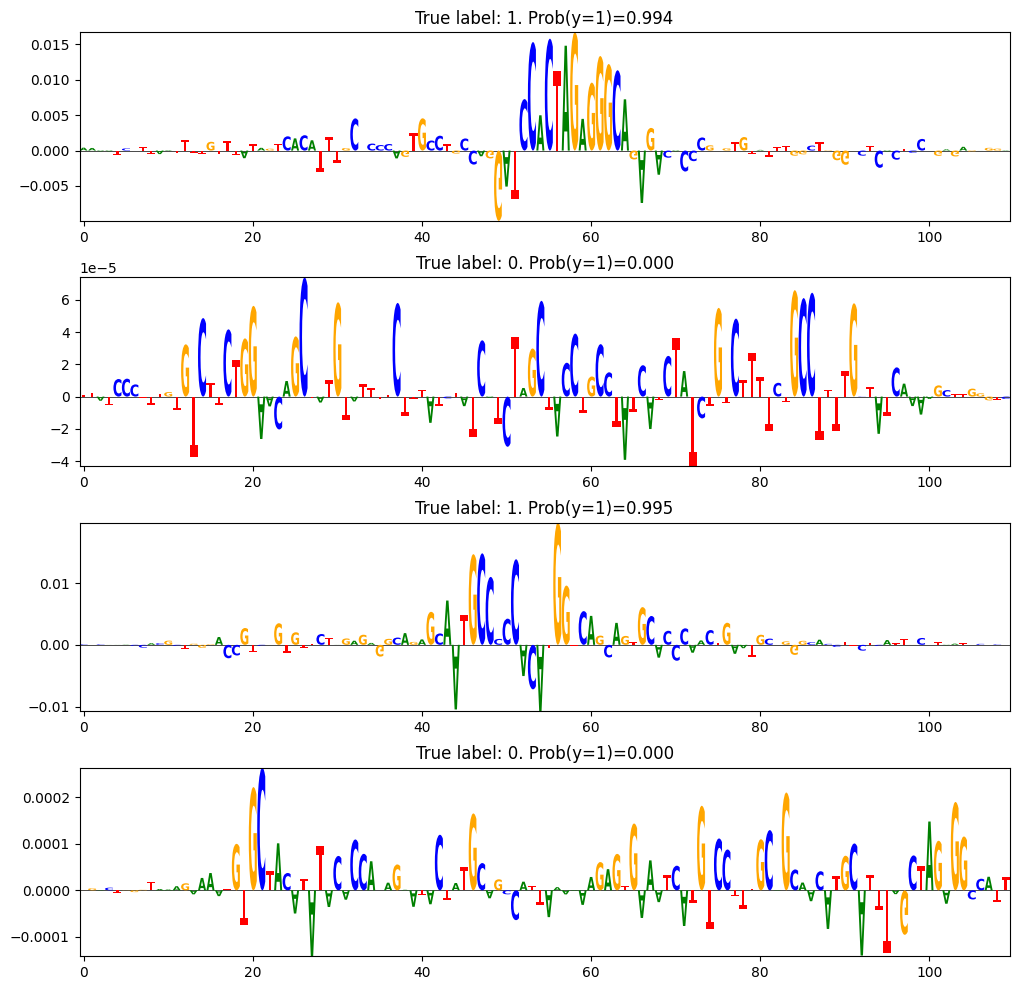

In [ ]:
torch.set_grad_enabled(True)
x.requires_grad_() # tell torch we will want gradients wrt x (which we don't normally need)
output = cnn_1d(x).squeeze()
output = torch.sigmoid(output)
dummy = torch.ones_like(output) # in a multiclass model this would be a one-hot encoding of y
output.backward(dummy) # to get derivative wrt to x
gradient_np = x.grad.detach().cpu().numpy()
output_np = output.detach().cpu().numpy()
saliency = gradient_np * x_cpu.numpy()
plt.figure(figsize = (12,12))
for i in range(1,5):
    ax = plt.subplot(4,1,i) #,sharey=ax)
    pwm_df = pd.DataFrame(data = saliency[i,:,:].transpose(), columns=("A","C","G","T"))
    logomaker.Logo(pwm_df, ax=ax) # CCGCGNGGNGGCAG or CTGCCNCCNCGCGG
    plt.title("True label: %i. Prob(y=1)=%.3f" % (y_cpu[i],output_np[i]))

plt.subplots_adjust(hspace = 0.3)

This is much more computationally efficient than in silico mutagenesis, requiring only ONE forward and backward pass. Compare the two interpretation methods: for the positive examples the same sequence regions are highlighted (although the saliency map is noisier outside that region).

### Other interpretation approaches

There's a nice compedium and associated `torch` code for a number methods [here](https://github.com/utkuozbulak/pytorch-cnn-visualizations). Some that I would add:
1. DeepLIFT  [paper](https://arxiv.org/abs/1704.02685) [code](https://github.com/kundajelab/deeplift) - no `pytorch` support sadly.
2. DeepSHAP [paper](https://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions) [code](https://github.com/slundberg/shap)
3. Influence functions. [paper](https://arxiv.org/abs/1703.04730) [code](https://github.com/kohpangwei/influence-release). A little different: finds which training points most strongly influence the current prediction.

## A more challenging task

CTCF binding is relatively easy to predict, mostly depending on homotypic binding with a strong motif. Here you'll attempt a more difficult task: predicting chromatin accessibility (as measured by ATAC-seq) for a mystery cell type (mysterious so you can fairly compete in the competition below!) Let's load data and split into training and validation - I've already removed chromosome 1 and 2 data as test set to be used in the competition at the end.

In [ ]:
atac_data = pd.read_csv(DATADIR + "ATAC_data.bed.gz", sep='\t', names=("chrom","start","end"))
atac_data = atac_data.sort_values(['chrom', 'start']) # actually already sorted but why not

validation_chromosomes = ["chr3","chr4"]
validation_data = atac_data[ atac_data['chrom'].isin(validation_chromosomes) ]

train_data = atac_data[ ~atac_data['chrom'].isin( validation_chromosomes ) ]

train_data.shape[0] / atac_data.shape[0], validation_data.shape[0] / atac_data.shape[0]

(0.812797461660497, 0.1872025383395029)

# Tasks

Make your own copy of this notebook complete the following questions by filling in the code and write-up sections. Feel free to add cells as needed.

## Wrapper function [2 points]

It will be helpful to make a wrapper function that does the following:
1. Make new `BedPeakDataset` and `DataLoader` objects for both training and validation data.
2. Instantiates an optimizer for the model.
3. Runs the training loop with early stopping.
4. Returns the fitted model, train and validation accuracies.

We've given a suggested signature for the wrapper function. You'll find the code snippets you need above although you will need to do some minor editing if you want the optional arguments to have the correct effects.

In [ ]:
# TODO make wrapper function.

def train_model(cnn_1d, train_data, validation_data, epochs=100, patience=10, verbose = True):
    """
    Train a 1D CNN model and record accuracy metrics.
    """
    # Move the model to the GPU here to make it runs there, and set "device" as above
    # TODO CODE
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cnn_1d = cnn_1d.to(device)

    # 1. Make new BedPeakDataset and DataLoader objects for both training and validation data.
    train_dataset = BedPeaksDataset(train_data, genome, cnn_1d.seq_len)
    validation_dataset = BedPeaksDataset(validation_data, genome, cnn_1d.seq_len)

    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1000, num_workers = 0)
    validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size=1000, num_workers = 0)

    # 2. Instantiates an optimizer for the model.
    # TODO CODE
    optimizer = torch.optim.Adam(cnn_1d.parameters(), lr=0.001)

    # 3. Run the training loop with early stopping.
    # TODO CODE
    best_acc = 0
    bad_epochs = 0
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        train_loss, train_acc = run_one_epoch(True, train_dataloader, cnn_1d, optimizer, device)
        val_loss, val_acc     = run_one_epoch(False, validation_dataloader, cnn_1d, optimizer, device)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    # 4. Return the fitted model (not strictly necessary since this happens "in place"), train and validation accuracies.
    # TODO CODE
    return cnn_1d, train_accs, val_accs

You should now be able to train a basic CNN with the same architechure as we used above for CTCF binding prediction.

In [ ]:
my_cnn1d = CNN_1d()
print(my_cnn1d.seq_len)
my_cnn1d
my_cnn1d, train_accs, val_accs = train_model(my_cnn1d, train_data, validation_data)

Receptive field: 30 Chunk size: 16 Number chunks: 5
110


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1542: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn(


Epoch 1: Train Acc=0.5739, Val Acc=0.6050
Epoch 2: Train Acc=0.6070, Val Acc=0.6247
Epoch 3: Train Acc=0.6166, Val Acc=0.6282
Epoch 4: Train Acc=0.6215, Val Acc=0.6482
Epoch 5: Train Acc=0.6367, Val Acc=0.6568
Epoch 6: Train Acc=0.6504, Val Acc=0.6753
Epoch 7: Train Acc=0.6589, Val Acc=0.6859
Epoch 8: Train Acc=0.6692, Val Acc=0.6949
Epoch 9: Train Acc=0.6769, Val Acc=0.7008
Epoch 10: Train Acc=0.6855, Val Acc=0.7008
Epoch 11: Train Acc=0.6940, Val Acc=0.7106
Epoch 12: Train Acc=0.6984, Val Acc=0.7165
Epoch 13: Train Acc=0.7079, Val Acc=0.7176
Epoch 14: Train Acc=0.7142, Val Acc=0.7132
Epoch 15: Train Acc=0.7192, Val Acc=0.7206
Epoch 16: Train Acc=0.7267, Val Acc=0.7239
Epoch 17: Train Acc=0.7291, Val Acc=0.7245
Epoch 18: Train Acc=0.7324, Val Acc=0.7305
Epoch 19: Train Acc=0.7366, Val Acc=0.7298
Epoch 20: Train Acc=0.7372, Val Acc=0.7276
Epoch 21: Train Acc=0.7410, Val Acc=0.7320
Epoch 22: Train Acc=0.7440, Val Acc=0.7327
Epoch 23: Train Acc=0.7467, Val Acc=0.7362
Epoch 24: Train Acc=

## Question 1 [4 points]

a. Find settings of `CNN_1d` that underfit (low train and validation accuracy) and plot the train and validation accuracy. [3 points]

Epoch 1: Train Acc=0.4998, Val Acc=0.4999
Epoch 2: Train Acc=0.4998, Val Acc=0.4999
Epoch 3: Train Acc=0.4999, Val Acc=0.5001
Epoch 4: Train Acc=0.5002, Val Acc=0.5001
Epoch 5: Train Acc=0.5002, Val Acc=0.5001
Epoch 6: Train Acc=0.5002, Val Acc=0.5001
Epoch 7: Train Acc=0.5002, Val Acc=0.5001
Epoch 8: Train Acc=0.5002, Val Acc=0.5001
Early stopping triggered.


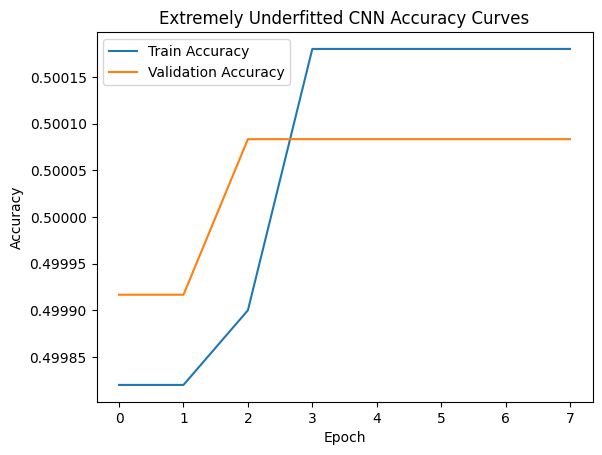

In [ ]:
# YOUR CODE HERE
class CNN_1d_underfit(nn.Module):
    def __init__(self, seq_len=110):
        super().__init__()
        self.seq_len = seq_len

        num_filters = 1
        kernel_size = 1
        pool_size = 8

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(pool_size)

        conv_output = seq_len - kernel_size + 1
        pooled_output = conv_output // pool_size
        fc_in_features = num_filters * pooled_output

        self.fc = nn.Linear(fc_in_features, 1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x).squeeze(dim=1)


my_cnn_underfit = CNN_1d_underfit(seq_len=cnn_1d.seq_len)

model, train_accs, val_accs = train_model(
    my_cnn_underfit,
    train_data,
    validation_data,
    epochs=20,
    patience=5
)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Extremely Underfitted CNN Accuracy Curves")
plt.legend()
plt.show()


b. Describe the setting choices you have made to underfit the data and explain why these settings contributed to a low train and validation accuracy. [1 point]

*Some of the settings choices I made to underfit the data include the following:
- For starters, I set num_filters = 1 so that were was only one convolutional filter. This limited number of convolutional filters make it so that the model has an extremely limited capacity to detect sequences in the input sequence. Furthermore, the sequence length is still 110, so this model's weak capacity is especially limiting because of the relatively long input sequence
- I also set the kernel size equal to 1. This means that our one convolutional filter can only look at 1 position at a time, so it can' capture meaningful motifs or patterns
- I also set the pool_size=8, which reduces the feature map significantly. This results to the discarding of majority of the spatial information. After pooling, the feature map is flattened before the fully connected layer, and this  contributes to losing spatial information (although this loss isn't as significant, the pooling is aggressive as it is)  
- I also created a minimal fully connected layer, which means that the classifier is extremely small. THis limits the ability to combine features effectively.

Combined, these settings make the model much too weak to learn the underlying patterns in the data. THe training accuracy is unable to imrpove because the network can't even fit the training set, let along accurately predict the output when assessing validation accuracy - the model isn't able to generalize or capture any patterns. Accuracy for both training and validation are nearly equivalent to random guessing (oscillating around 50%) because thie model is made to have a network with an extremely limited capacity.  

## Question 2 [4 points]

a. Find settings of `CNN_1d` that that overfit (high train accuracy but low validation accuracy). [3 points]

Epoch 1: Train Acc=0.5640, Val Acc=0.5373
Epoch 2: Train Acc=0.6044, Val Acc=0.5836
Epoch 3: Train Acc=0.6253, Val Acc=0.6233
Epoch 4: Train Acc=0.6755, Val Acc=0.6631
Epoch 5: Train Acc=0.7115, Val Acc=0.6651
Epoch 6: Train Acc=0.7273, Val Acc=0.6815
Epoch 7: Train Acc=0.7444, Val Acc=0.6862
Epoch 8: Train Acc=0.7555, Val Acc=0.6951
Epoch 9: Train Acc=0.7644, Val Acc=0.7115
Epoch 10: Train Acc=0.7686, Val Acc=0.7133
Epoch 11: Train Acc=0.7684, Val Acc=0.7088
Epoch 12: Train Acc=0.7815, Val Acc=0.7000
Epoch 13: Train Acc=0.7870, Val Acc=0.6688
Epoch 14: Train Acc=0.7860, Val Acc=0.6809
Epoch 15: Train Acc=0.7833, Val Acc=0.7066
Epoch 16: Train Acc=0.8064, Val Acc=0.7059
Epoch 17: Train Acc=0.8162, Val Acc=0.6979
Epoch 18: Train Acc=0.8285, Val Acc=0.7009
Epoch 19: Train Acc=0.8410, Val Acc=0.7102
Epoch 20: Train Acc=0.8542, Val Acc=0.7140
Epoch 21: Train Acc=0.8663, Val Acc=0.7152
Epoch 22: Train Acc=0.8797, Val Acc=0.7119
Epoch 23: Train Acc=0.8942, Val Acc=0.7093
Epoch 24: Train Acc=

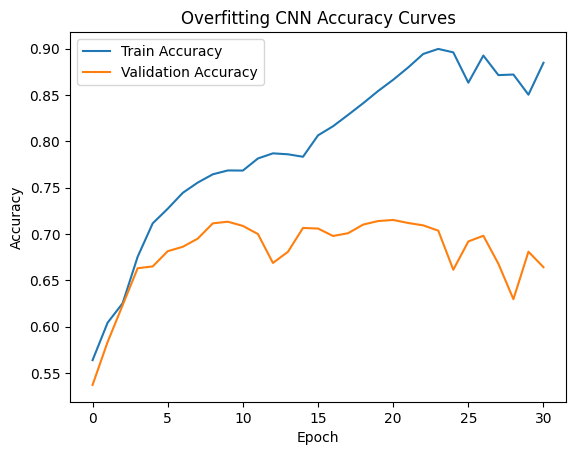

In [ ]:
# YOUR CODE HERE
class CNN_1d_overfit(nn.Module):
    def __init__(self, seq_len=110):
        super().__init__()
        self.seq_len = seq_len


        num_filters = 128
        kernel_size = 9
        pool_size = 2

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(pool_size)

        conv_output = seq_len - kernel_size + 1
        pooled_output = conv_output // pool_size
        fc_in_features = num_filters * pooled_output


        self.fc1 = nn.Linear(fc_in_features, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x).squeeze(dim=1)

my_cnn_overfit = CNN_1d_overfit(seq_len=cnn_1d.seq_len)

model, train_accs, val_accs = train_model(
    my_cnn_overfit,
    train_data,
    validation_data,
    epochs=50,
    patience=10
)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overfitting CNN Accuracy Curves")
plt.legend()
plt.show()



b. Describe the setting choices you have made to overfit the data and explain why these settings contributed to a high train and low validation accuracy. [1 point]

**To make the model overfit, I increased the complexity of the CNN. For example, I set the num_filters to 128 (which is an extremely large number of filters) so that the model could learn many detailed patterns from the training data, to the extent of memorizing the data, allowing it to fit to the training data closely. I also used a larger kernel size (5) which allowed each filter to capture longer local dependencies. Furthermore, I reduced the pool_size to 2, which preserved more spatial information. I also increased the number of neurons in the fully connected layer so that the classifier could memorize specific training patterns. Training for more epochs without including dropout made sure that the model had no regularization to prevent overfitting. These settings set up the model to make sure that it had the capacity and time to perfectly fit the training data. Given these settings, it only makes sense that it will fail to generalize, which we can see is shown by the low validation accuracy relative to training accuracy.  **

## Question 3  [6 points]

a. Carefully explore varying one architectural choice (e.g.  depth, number of channels, filter width, regularization, pooling factor, optimizer, learning rate, batch size, activation function, normalization, or skip connections). Report the final train and validation accuracy as a function of this choice.

For example you might vary the number of convolutional layers from 1 to 4, keeping everything else the same, and plot validation accuracy vs number of layers. [4 points]


Training model with 1 convolutional layer(s)...
Epoch 1: Train Acc=0.5649, Val Acc=0.5724
Epoch 2: Train Acc=0.5929, Val Acc=0.5850
Epoch 3: Train Acc=0.6009, Val Acc=0.6039
Epoch 4: Train Acc=0.6069, Val Acc=0.6190
Epoch 5: Train Acc=0.6165, Val Acc=0.6241
Epoch 6: Train Acc=0.6236, Val Acc=0.6289
Epoch 7: Train Acc=0.6302, Val Acc=0.6343
Epoch 8: Train Acc=0.6363, Val Acc=0.6394
Epoch 9: Train Acc=0.6405, Val Acc=0.6444
Epoch 10: Train Acc=0.6435, Val Acc=0.6495
Epoch 11: Train Acc=0.6468, Val Acc=0.6530
Epoch 12: Train Acc=0.6506, Val Acc=0.6561
Epoch 13: Train Acc=0.6524, Val Acc=0.6569
Epoch 14: Train Acc=0.6546, Val Acc=0.6571
Epoch 15: Train Acc=0.6564, Val Acc=0.6597
Epoch 16: Train Acc=0.6579, Val Acc=0.6605
Epoch 17: Train Acc=0.6593, Val Acc=0.6617
Epoch 18: Train Acc=0.6610, Val Acc=0.6617
Epoch 19: Train Acc=0.6635, Val Acc=0.6651
Epoch 20: Train Acc=0.6656, Val Acc=0.6665

Training model with 2 convolutional layer(s)...
Epoch 1: Train Acc=0.5604, Val Acc=0.5636
Epoch 2: 

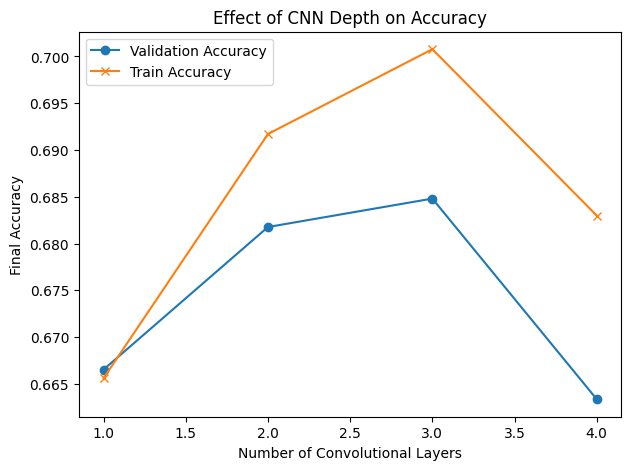

In [ ]:
class CNN_1d_variable(nn.Module):
    def __init__(self, seq_len=110, num_layers=1, num_filters=16, kernel_size=3, pool_size=2):
        super().__init__()
        self.seq_len = seq_len

        layers = []
        in_channels = 4
        out_channels = num_filters

        for i in range(num_layers):
            conv = nn.Conv1d(in_channels, out_channels, kernel_size)
            layers += [conv, nn.ReLU(), nn.MaxPool1d(pool_size)]
            in_channels = out_channels

        self.conv_layers = nn.Sequential(*layers)

        conv_output = seq_len
        for _ in range(num_layers):
            conv_output = (conv_output - kernel_size + 1) // pool_size
        fc_in_features = out_channels * conv_output

        self.fc = nn.Linear(fc_in_features, 1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc(x).squeeze(dim=1)


num_layers_list = [1, 2, 3, 4]
train_accuracies = []
val_accuracies = []

for n_layers in num_layers_list:
    print(f"\nTraining model with {n_layers} convolutional layer(s)...")

    model = CNN_1d_variable(seq_len=cnn_1d.seq_len, num_layers=n_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trained_model, train_accs, val_accs = train_model(
        model,
        train_data,
        validation_data,
        epochs=20,
        patience=5
    )

    train_accuracies.append(train_accs[-1])
    val_accuracies.append(val_accs[-1])

plt.figure(figsize=(7,5))
plt.plot(num_layers_list, val_accuracies, marker='o', label="Validation Accuracy")
plt.plot(num_layers_list, train_accuracies, marker='x', label="Train Accuracy")
plt.xlabel("Number of Convolutional Layers")
plt.ylabel("Final Accuracy")
plt.title("Effect of CNN Depth on Accuracy")
plt.legend()
plt.show()

b. For your selected architectural choice, discuss how and why varying this option affected your training and validation accuracy. [2 points]

*In this experiment, I varied the number of convolutional layers in the CNN from 1 to 4 while keeping all other hyperparameters fixed. I noticed that when I increased the number of layers from 1 to 2, training and validation accuracy improved (even if it was incrementally) indicating that the model benefitted from additional feature extraction capacity.

However, when I added 3 or even 4 layers, I didn't notice any significant improvement, and as the graph shows that although training accuracy rose slightly, the validation accuracy plateaured around 67%.

This makes me think that the more you increase the number of convolutional layers, the more the model starts to overfit to the training data, making it harder to optimize on the available dataset, validation dataset, or even new data. Increasign from 1 to 2 layers is helpful, so there must be diminishing benefits after you reach the ideal number of layers for the particular data you are working with.*



## Question 4 [8 points]

a. Get as good validation accuracy as you can! Vary at least one thing that you didn't explore in Question 3, and show (with plots) or describe how you got to your final model. [4 points]

Optionally you can try some more advanced extensions, e.g.
1. Adding some [Recurrent Layers](https://pytorch.org/docs/stable/nn.html#recurrent-layers). Be warned that `torch` assumes the opposite dimensions for convolutional vs recurrent layers so you'll want to use `torch.transpose` appropriately.
2. Transcription factors can bind to either strand of the DNA so you might want to include the [reverse complement](https://www.bx.psu.edu/old/courses/bx-fall08/definitions.html) (RC) in addition to the normal input. The simplest way to do this would be to train on both the original sequence and the RC (a form of data augmentation). Slightly fancier: run a copy of the network on the RC and take the max of the output from the two networks. Fancier approach here: https://www.biorxiv.org/content/10.1101/103663v1
3. Changing `BedPeaksDataset` to generate more negative examples in the space between peaks (although you'd only want to do this on the training data so you keep a fixed validation set). You will want to "cancel out" the additional negative examples by downweighting them in the loss.


Training with dropout=0.2
Epoch 1: Train Acc=0.5674, Val Acc=0.5921
Epoch 2: Train Acc=0.6064, Val Acc=0.6247
Epoch 3: Train Acc=0.6212, Val Acc=0.6403
Epoch 4: Train Acc=0.6469, Val Acc=0.6286
Epoch 5: Train Acc=0.6888, Val Acc=0.7004
Epoch 6: Train Acc=0.7099, Val Acc=0.7107
Epoch 7: Train Acc=0.7249, Val Acc=0.7138
Epoch 8: Train Acc=0.7373, Val Acc=0.7134
Epoch 9: Train Acc=0.7481, Val Acc=0.7134
Epoch 10: Train Acc=0.7600, Val Acc=0.7173
Epoch 11: Train Acc=0.7746, Val Acc=0.7203
Epoch 12: Train Acc=0.7823, Val Acc=0.7228
Epoch 13: Train Acc=0.7877, Val Acc=0.7178
Epoch 14: Train Acc=0.7820, Val Acc=0.7296
Epoch 15: Train Acc=0.7906, Val Acc=0.6944
Epoch 16: Train Acc=0.7929, Val Acc=0.7123
Epoch 17: Train Acc=0.8031, Val Acc=0.7107
Epoch 18: Train Acc=0.8140, Val Acc=0.7211
Epoch 19: Train Acc=0.8237, Val Acc=0.7271
Epoch 20: Train Acc=0.8332, Val Acc=0.7272
Epoch 21: Train Acc=0.8431, Val Acc=0.7225
Epoch 22: Train Acc=0.8439, Val Acc=0.7179
Epoch 23: Train Acc=0.8474, Val Acc=

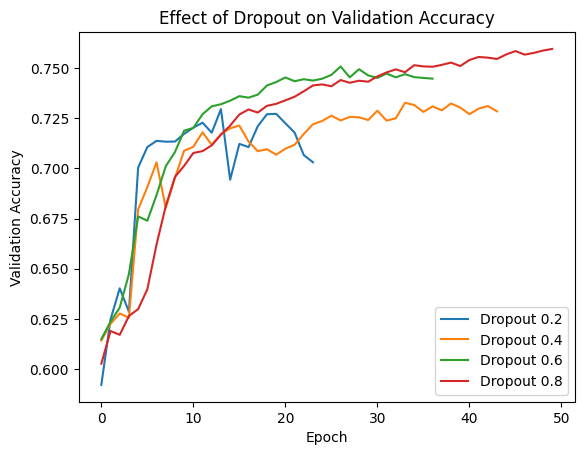

In [ ]:
class CNN_1d_overfit_dropout(nn.Module):
    def __init__(self, seq_len=110, dropout=0.5):
        super().__init__()
        self.seq_len = seq_len

        num_filters = 128
        kernel_size = 9
        pool_size = 2

        self.conv1 = nn.Conv1d(4, num_filters, kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(pool_size)
        self.dropout = nn.Dropout(dropout)

        conv_output = seq_len - kernel_size + 1
        pooled_output = conv_output // pool_size
        fc_in_features = num_filters * pooled_output

        self.fc1 = nn.Linear(fc_in_features, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x).squeeze(dim=1)
dropout_values = [0.2, 0.4, 0.6, 0.8]
results = {}

for d in dropout_values:
    print(f"\nTraining with dropout={d}")
    model = CNN_1d_overfit_dropout(seq_len=cnn_1d.seq_len, dropout=d)
    trained_model, train_accs, val_accs = train_model(
        model, train_data, validation_data, epochs=50, patience=10
    )
    results[d] = (train_accs, val_accs)
    plt.plot(val_accs, label=f"Dropout {d}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Dropout on Validation Accuracy")
plt.legend()
plt.show()


b. What gave you the biggest boost in performance? Why do you think that is? [2 points]

*The biggest boost in performance in my model came from increasing the dropout rate in the fully connected layers. By using a higher dropout (e.g., 0.8 which gave me the highest validation accuracy relative to the other dropout rates), the network’s validation accuracy improved compared to lower dropout rates.

I think this happened because dropout prevents the model from overfitting to the training data. When the network is large and able to memorize the training set, it can easily achieve high training accuracy but poor generalization. Dropout helps to “turns off” neurons during training, forcing the model to learn more of the general features instead of memorizing the training examples, which improves performance on the validation set. I was hoping to use this to my advantage and see how a range in dropout rates affects the validation accuracy, and if it isn't a significant increase, I think it definitely contributed to higher validation accuracy.*



c.  Use some model interpretability technique to visualize why the model has made the assignments it did for a few examples. This can be one of the methods shown above (in silico mutagenesis or saliency maps) or one of the methods linked under *Other interpretation approaches*. [2 points]

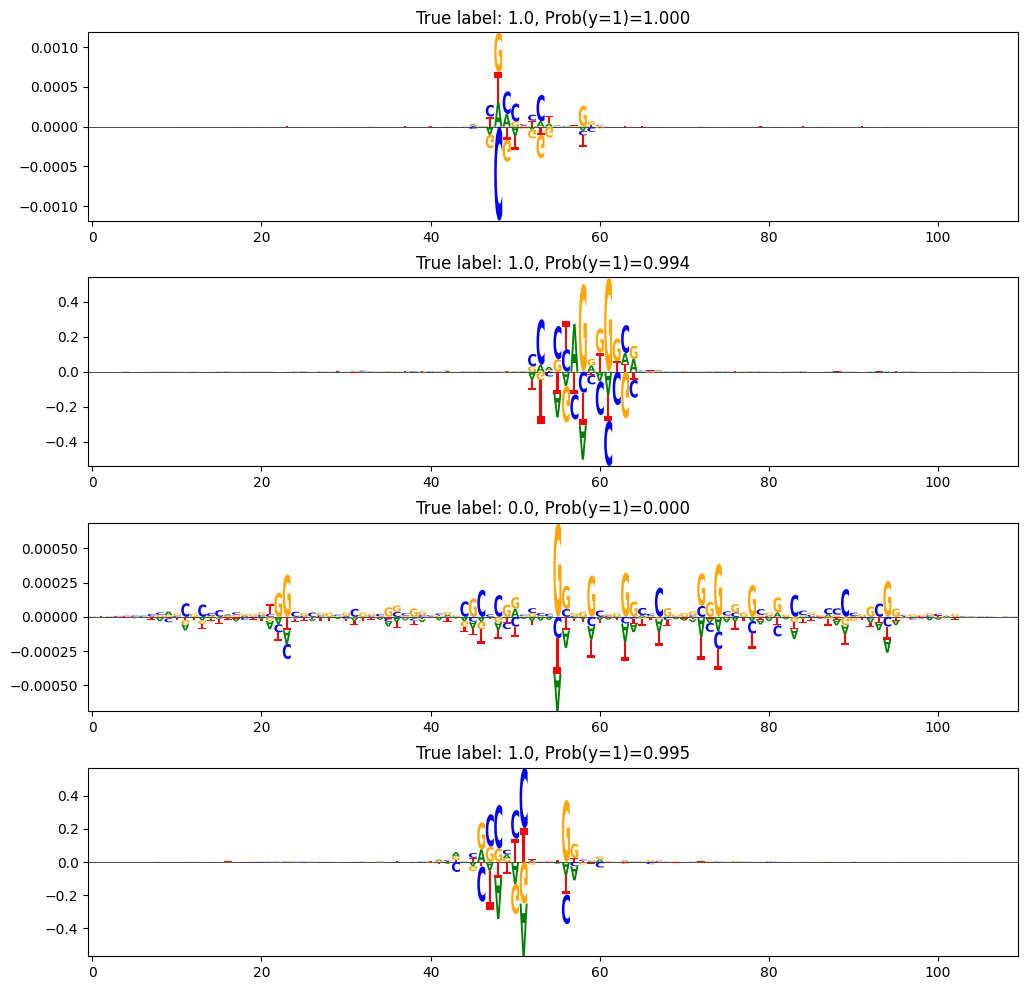

In [ ]:
torch.set_grad_enabled(False)

for x_cpu, y_cpu in validation_dataloader:
    x = x_cpu.to(device)  # move to GPU
    y = y_cpu.to(device)

    output = cnn_1d(x).squeeze()
    output = torch.sigmoid(output)

    batch_size, num_channels, seq_len = x.shape
    delta_output = torch.zeros(batch_size, num_channels, seq_len, device=device)

    for pos in range(seq_len):
        for nt_idx in range(4):
            x_mut = x.clone()
            x_mut[:, :, pos] = 0.0
            x_mut[:, nt_idx, pos] = 1.0
            output_mut = torch.sigmoid(cnn_1d(x_mut).squeeze())
            delta_output[:, nt_idx, pos] = output_mut - output

    break

delta_output_np = delta_output.detach().cpu().numpy()
delta_output_np -= delta_output_np.mean(1, keepdims=True)

output_np = output.detach().cpu().numpy()

plt.figure(figsize=(12, 12))
for i in range(4):
    ax = plt.subplot(4,1,i+1)
    pwm_df = pd.DataFrame(data=delta_output_np[i,:,:].transpose(), columns=("A","C","G","T"))
    logomaker.Logo(pwm_df, ax=ax)
    plt.title(f"True label: {y_cpu[i].item()}, Prob(y=1)={output_np[i]:.3f}")

plt.subplots_adjust(hspace=0.3)
plt.show()





## Question 5  [6 points]

The final task is to submit your best performing model's predictions on chromosomes 1 and 2 to [our ModelShare competition](https://www.modelshare.org/detail/model:1484).

You can change what train/validation split you use here also if you want: e.g. you could do K-fold cross-validation or even retrain including the validation data if you think it will help (although early stopping may not work any more).

First we'll need to load the test regions:

In [ ]:
test_data = pd.read_csv(DATADIR + "ATAC_test_regions.bed.gz", sep='\t', names=("chrom","start","end"))
test_data.head(10)

,chrom,start,end
0,chr1,713980,714180
1,chr1,2159194,2159394
2,chr1,1185163,1185363
3,chr1,2721699,2721899
4,chr1,2232837,2233037
5,chr1,2462557,2462757
6,chr1,2601580,2601780
7,chr1,2638010,2638210
8,chr1,3393795,3393995
9,chr1,3418525,3418725


Unlike the training data we've included random (in number and in genomic position) negative (no binding) regions in this bed file since otherwise you'd know implicitly that all the loaded regions are positives!

We'll use a new `Dataset` class and `DataLoader` to match predictions on the test data in batches:

In [ ]:
class BedPeaksDatasetTest(torch.utils.data.IterableDataset):

    def __init__(self, atac_data, genome, context_length):
        super(BedPeaksDatasetTest, self).__init__()
        self.context_length = context_length
        self.atac_data = atac_data
        self.genome = genome

    def __iter__(self):
        for row in self.atac_data.itertuples():
            midpoint = int(.5 * (row.start + row.end))
            seq = self.genome[row.chrom][ midpoint - self.context_length//2:midpoint + self.context_length//2]
            yield(one_hot(seq))

test_dataset = BedPeaksDatasetTest(test_data, genome, my_cnn1d.seq_len)
# you can always use a smaller batchsize if you ended up using a really big model
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, num_workers = 0)

outputs = []
for x in test_dataloader: # iterate over batches
    x = x.to(device)
    output = my_cnn1d(x).squeeze() # your awesome model here!
    output = torch.sigmoid(output)
    output_np = output.detach().cpu().numpy()
    outputs.append(output_np)
output_np = np.concatenate(outputs)

predicted_values=output_np.tolist() # Create list of your predictions from test data
predicted_values[0:5] # check these aren't NaN or Inf which would suggest some numerical problem

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1542: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn(


[0.7153010964393616,
 0.9740739464759827,
 0.3972947895526886,
 0.39096924662590027,
 0.06113983318209648]